## Notebook: Financial Analytics
*PADS - Programa Avançado em Data Science*

Insper

**Paloma Vaissman Uribe**





## 1. Exploring VAR - Vector Autoregression Models
Based on https://www.statsmodels.org/dev/vector_ar.html

In [1]:

import numpy as np
import pandas
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.base.datetools import dates_from_str

mdata = sm.datasets.macrodata.load_pandas().data

# prepare the dates index
dates = mdata[['year', 'quarter']].astype(int).astype(str)
quarterly = dates["year"] + "Q" + dates["quarter"]
quarterly = dates_from_str(quarterly)
mdata = mdata[['realgdp','realcons','realinv']]
mdata.index = pandas.DatetimeIndex(quarterly)
data = np.log(mdata).diff().dropna()

# make a VAR model
model = VAR(data)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


In [2]:
data

,realgdp,realcons,realinv
1959-06-30,0.024942,0.015286,0.080213
1959-09-30,-0.001193,0.010386,-0.072131
1959-12-31,0.003495,0.001084,0.034425
1960-03-31,0.022190,0.009534,0.102664
1960-06-30,-0.004685,0.012572,-0.106694
...,...,...,...
2008-09-30,-0.006781,-0.008948,-0.017836
2008-12-31,-0.013805,-0.007843,-0.069165
2009-03-31,-0.016612,0.001511,-0.175598
2009-06-30,-0.001851,-0.002196,-0.067561


In [3]:
results = model.fit(1)
results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 28, Nov, 2025
Time:                     22:40:39
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -27.7388
Nobs:                     201.000    HQIC:                  -27.8562
Log likelihood:           1963.94    FPE:                7.37174e-13
AIC:                     -27.9360    Det(Omega_mle):     6.94859e-13
--------------------------------------------------------------------
Results for equation realgdp
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.003580         0.000911            3.928           0.000
L1.realgdp         -0.338056         0.172084           -1.964           0.049
L1.realcons         0.746283         0.130411            5.723    

In [4]:
# selection of orders of VAR: optimizing using information criteria
model.select_order(15)
results = model.fit(maxlags=15, ic='aic')
lag_order = results.k_ar
print("chosen VAR order is = " + str(lag_order))

chosen VAR order is = 3


In [5]:
# forecasting: have to pass initial values
results.forecast(data.values[-lag_order:], 10)

array([[ 0.00616044,  0.00500006,  0.00916198],
       [ 0.00427559,  0.00344836, -0.00238478],
       [ 0.00416634,  0.0070728 , -0.01193629],
       [ 0.00557873,  0.00642784,  0.00147152],
       [ 0.00626431,  0.00666715,  0.00379567],
       [ 0.00651738,  0.00764936,  0.00198474],
       [ 0.00690284,  0.00760909,  0.00548495],
       [ 0.00714517,  0.00775843,  0.00620737],
       [ 0.007258  ,  0.0079993 ,  0.00602391],
       [ 0.00738975,  0.00804623,  0.00690895]])

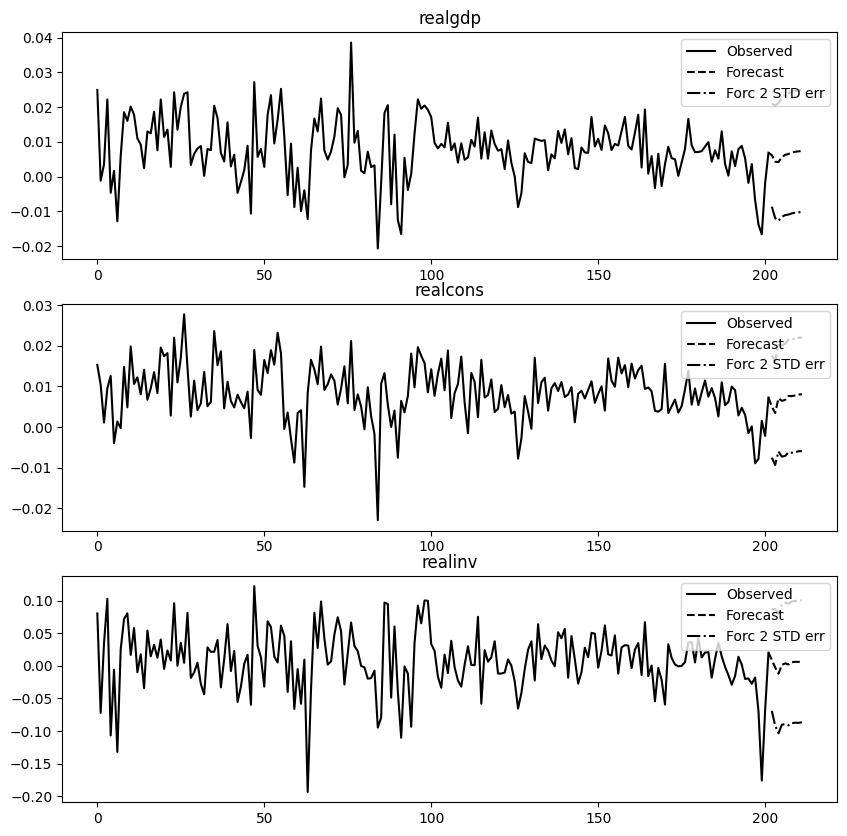

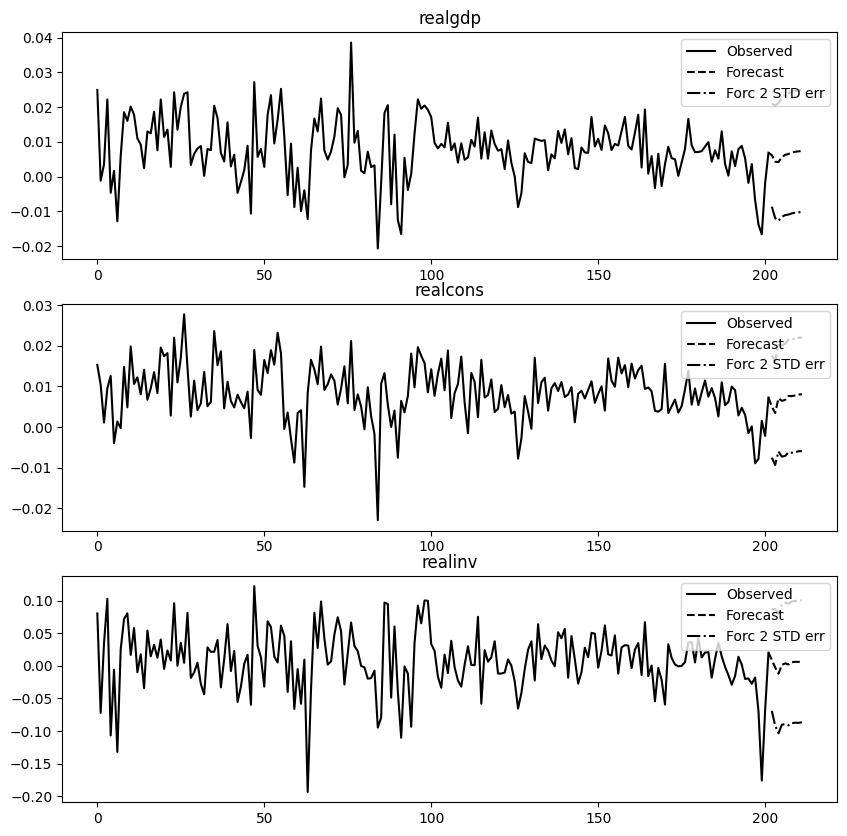

In [6]:
results.plot_forecast(10)

Impulse response function: how a system responds to a sudden change or impulse in its input in the time domain. In economics, and especially in contemporary macroeconomic modeling, impulse response functions are used to describe how the economy reacts over time to exogenous impulses, which economists usually call shocks, and are often modeled in the context of a vector autoregression.

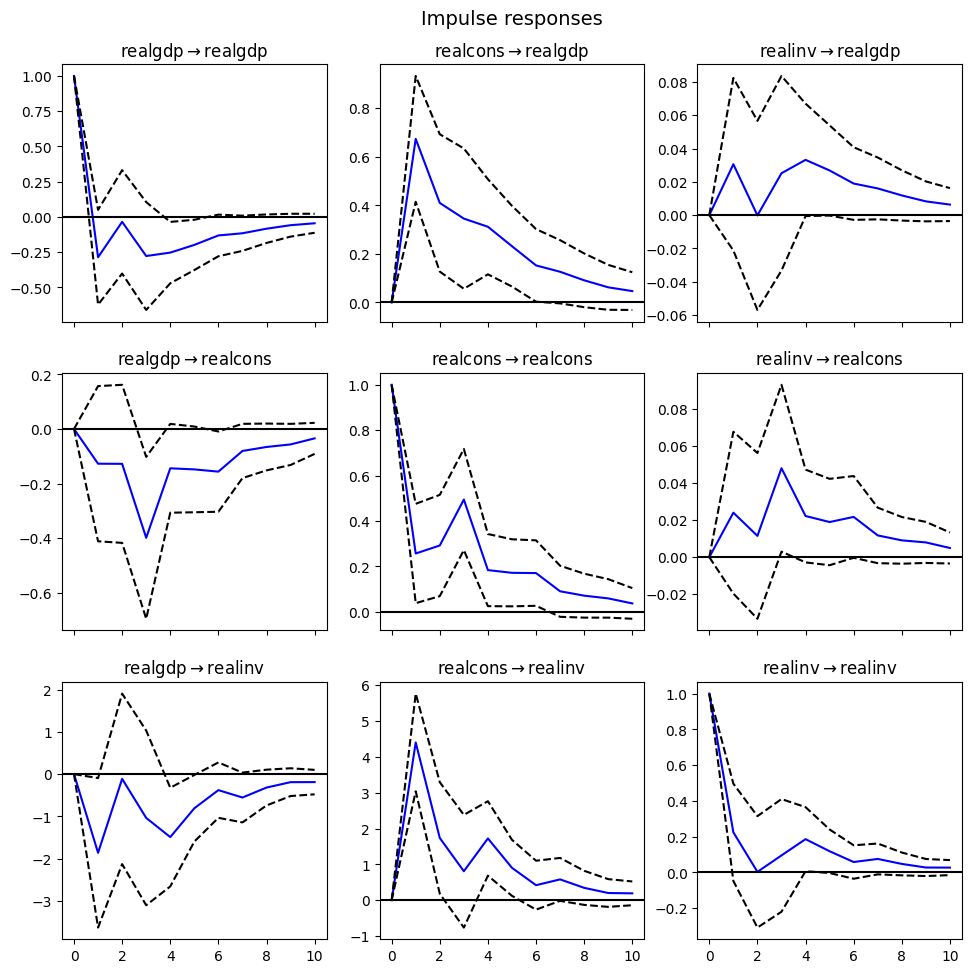

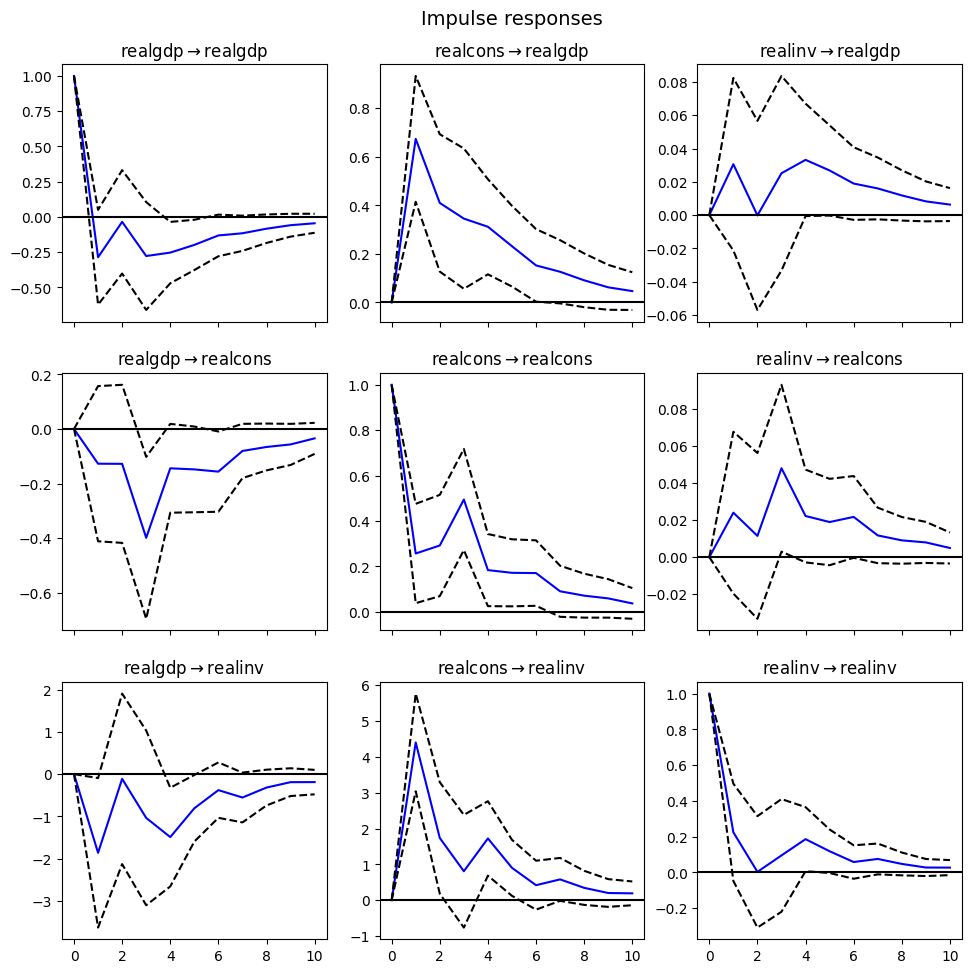

In [7]:
# impulse response function
irf = results.irf(10)
irf.plot(orth=False)

## 2. Exploring cointegration
Based on:
- https://github.com/KidQuant/Pairs-Trading-With-Python/blob/master/PairsTrading.ipynb
- https://www.programcreek.com/python/example/122726/statsmodels.tsa.stattools.coint
- https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.coint.html#
- https://quantopian-archive.netlify.app/notebooks/notebooks/quantopian_notebook_145.html

In [35]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import coint
from pandas_datareader import data as pdr
import datetime
import yfinance as yf
import matplotlib.pyplot as plt

## A note on how to detect cointegration

Steps:

1. Test for a unit root in each component series individually, using the univariate unit root tests, say ADF, KPSS, PP test.

2. In the case we don't reject the null hypothesis of unit root, we can apply **Engle-Granger test**:

It works in two steps: first, a regression is estimated between the variables and the residuals are extracted. Second, a unit root test, such as the Augmented Dickey-Fuller (ADF) test, is applied to the residuals to check if they are stationary. If the residuals are stationary, the original variables are considered cointegrated."

The `coint` function from statsmodels.tsa.stattools performs the Engle-Granger two-step cointegration test.

### Simulating some example data
- Simulating prices using cumulative returns;
- Now we generate Y. Remember that Y is supposed to have a deep economic link to X, so the price of Y should vary pretty similarly. We model this by taking X, shifting it up and adding some random noise drawn from a normal distribution.

<Axes: >

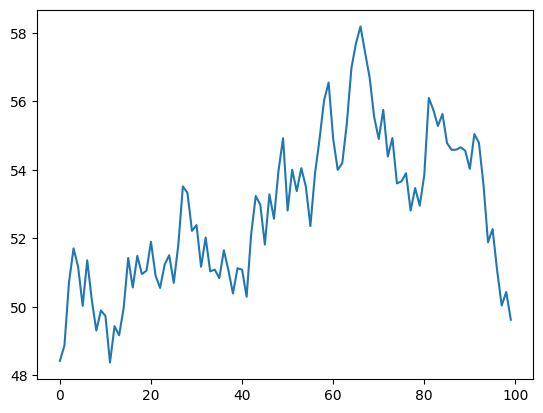

In [30]:
X_returns = np.random.normal(0, 1, 100) # generating random normal var
X = pd.Series(np.cumsum(X_returns), name='X') + 50
X.plot()

<Axes: >

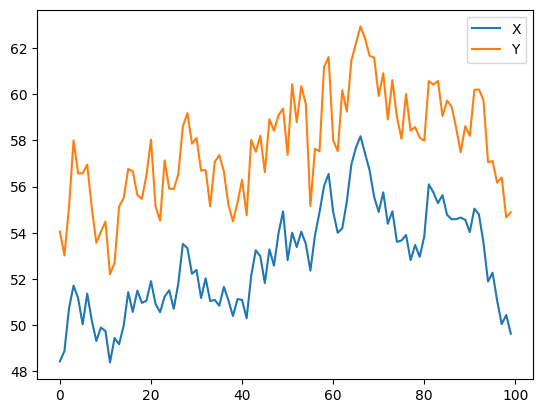

In [31]:
some_noise = np.random.normal(0, 1, 100)
Y = X + 5 + some_noise
Y.name = 'Y'
pd.concat([X, Y], axis=1).plot()

Testing for cointegration. But first, we can compare cointegration vs correlation.

In [32]:
X.corr(Y)

np.float64(0.9273678099454663)

In [33]:
# compute the p-value of the cointegration test
# Test for no-cointegration of a univariate equation as H0
# will inform us as to whether the spread btwn the 2 timeseries is stationary
# around its mean
score, pvalue, _ = coint(X,Y)
print(pvalue)

1.5239505499170159e-09


With a low value for test p-value, we cannot reject the cointegration the hypothesis of residuals being I(0) - stationarity.

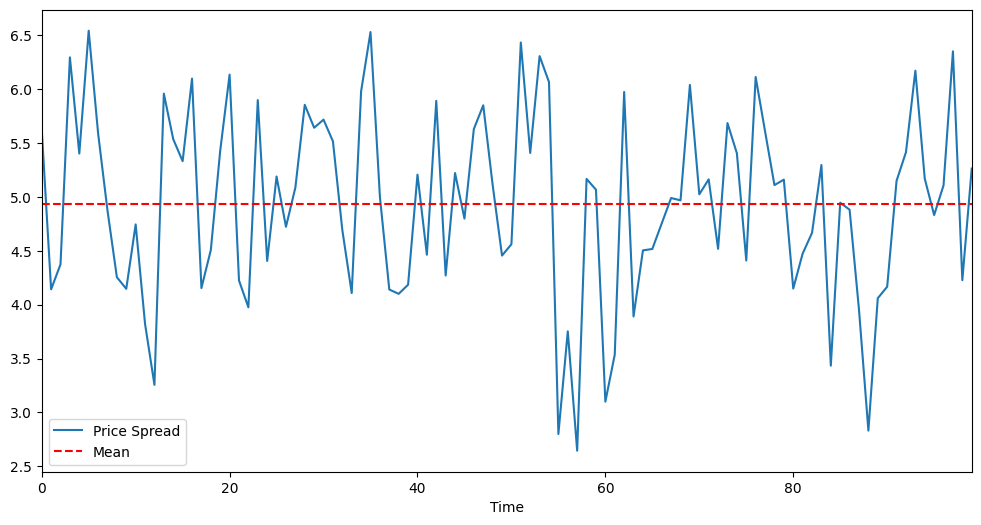

In [34]:
plt.figure(figsize=(12,6))
(Y - X).plot() # Plot the spread
plt.axhline((Y - X).mean(), color='red', linestyle='--') # Add the mean
plt.xlabel('Time')
plt.xlim(0,99)
plt.legend(['Price Spread', 'Mean']);

### Correlation is not cointegration:

Another simulates example is the following:

(0.0, 99.0)

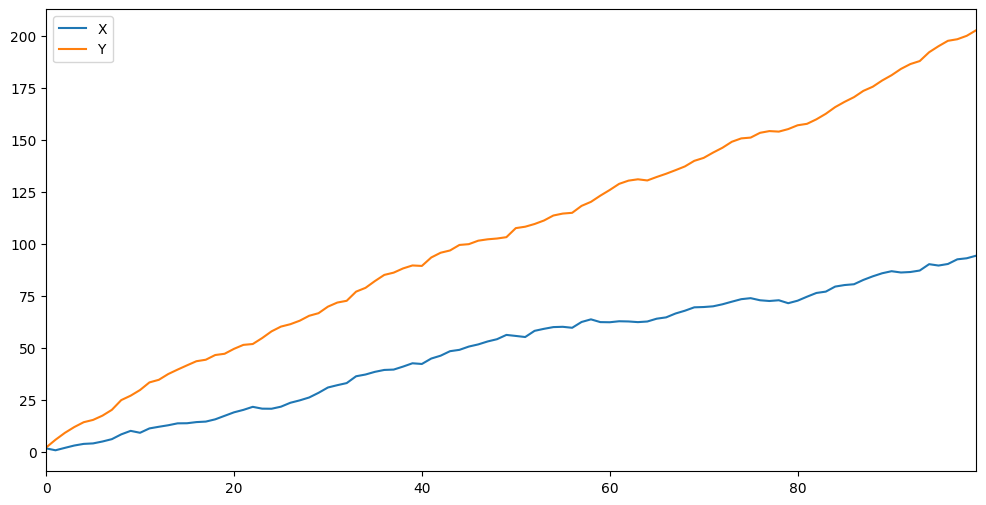

In [43]:
X_returns = np.random.normal(1, 1, 100)
Y_returns = np.random.normal(2, 1, 100)

X_diverging = pd.Series(np.cumsum(X_returns), name='X')
Y_diverging = pd.Series(np.cumsum(Y_returns), name='Y')


pd.concat([X_diverging, Y_diverging], axis=1).plot(figsize=(12,6));
plt.xlim(0, 99)

In [44]:
print('Correlation: ' + str(X_diverging.corr(Y_diverging)))
score, pvalue, _ = coint(X_diverging,Y_diverging)
print('Cointegration test p-value: ' + str(pvalue))

Correlation: 0.9936099205123949
Cointegration test p-value: 0.7523500720747303


### Real example:
Now a real example of detecting pair trading strategies.

In [36]:
start = datetime.datetime(2013, 1, 1)
end = datetime.datetime(2018, 1, 1)

ticker_list = ['AAPL', 'ADBE', 'ORCL', 'EBAY', 'MSFT', 'QCOM', 'HPQ', 'AMD', 'IBM', 'SPY']

df = yf.download(ticker_list, start=start, end=end)['Close']

/tmp/ipython-input-3585329895.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_list, start=start, end=end)['Close']
[*********************100%***********************]  10 of 10 completed


In [37]:
df

Ticker,AAPL,ADBE,AMD,EBAY,HPQ,IBM,MSFT,ORCL,QCOM,SPY
Date,,,,,,,,,,
2013-01-02,16.612209,38.340000,2.53,20.143671,4.630522,113.857239,22.242884,28.839972,45.717426,116.953865
2013-01-03,16.402523,37.750000,2.49,19.715164,4.667517,113.231010,21.944916,28.524071,45.505615,116.689621
2013-01-04,15.945637,38.130001,2.59,19.839211,4.667517,112.488739,21.534203,28.773472,44.834850,117.202103
2013-01-07,15.851841,37.939999,2.67,20.113605,4.676767,111.995857,21.493935,28.623833,45.194942,116.881821
2013-01-08,15.894504,38.139999,2.67,19.801622,4.744590,111.839302,21.381193,28.632137,45.124340,116.545525
...,...,...,...,...,...,...,...,...,...,...
2017-12-22,40.985916,175.000000,10.54,33.723557,16.513344,102.822487,78.645721,42.007748,52.838741,236.793823
2017-12-26,39.946098,174.440002,10.46,33.884304,16.490046,103.045013,78.544533,42.069832,52.487728,236.510590
2017-12-27,39.953129,175.360001,10.53,33.589596,16.521111,103.247269,78.829651,42.025471,52.683643,236.625656


In [46]:
# function to build log returns from a dataframe
def log_returns(df):
  import numpy as np
  df_ = df.copy()
  for stock in df.columns:
      df_[stock] = np.log(df_[stock]).diff()
  return df_.dropna()

In [47]:
# applying the function
daily_returns = log_returns(df)
daily_returns

Ticker,AAPL,ADBE,AMD,EBAY,HPQ,IBM,MSFT,ORCL,QCOM,SPY
Date,,,,,,,,,,
2013-01-03,-0.012703,-0.015508,-0.015937,-0.021502,0.007958,-0.005515,-0.013487,-0.011014,-0.004644,-0.002262
2013-01-04,-0.028250,0.010016,0.039375,0.006272,0.000000,-0.006577,-0.018893,0.008706,-0.014850,0.004382
2013-01-07,-0.005900,-0.004995,0.030421,0.013736,0.001980,-0.004391,-0.001872,-0.005214,0.007999,-0.002736
2013-01-08,0.002688,0.005258,0.000000,-0.015633,0.014398,-0.001399,-0.005259,0.000290,-0.001563,-0.002881
2013-01-09,-0.015752,0.013542,-0.015095,0.001517,0.029452,-0.002856,0.005634,0.000581,0.015063,0.002539
...,...,...,...,...,...,...,...,...,...,...
2017-12-22,0.000000,0.002517,-0.032667,-0.001323,0.000470,0.006579,0.000117,0.001691,0.005267,-0.000262
2017-12-26,-0.025697,-0.003205,-0.007619,0.004755,-0.001412,0.002162,-0.001287,0.001477,-0.006665,-0.001197
2017-12-27,0.000176,0.005260,0.006670,-0.008736,0.001882,0.001961,0.003623,-0.001055,0.003726,0.000486


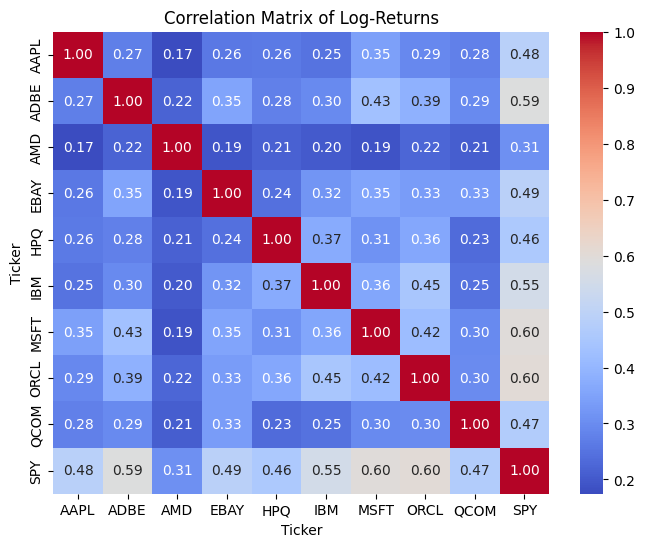

In [48]:
# matrix correlation of log-returns

import seaborn as sns
correlation_matrix = daily_returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Log-Returns')
plt.show()

Function to detect cointegrated pairs:

In [38]:
def find_cointegrated_pairs(data):
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = data.keys()
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

In [39]:
scores, pvalues, pairs = find_cointegrated_pairs(df)
pairs

[('AAPL', 'ORCL'),
 ('AAPL', 'SPY'),
 ('ADBE', 'EBAY'),
 ('ADBE', 'MSFT'),
 ('EBAY', 'MSFT'),
 ('HPQ', 'ORCL')]

In [40]:
# picking one example
S1 = df['ADBE']
S2 = df['MSFT']

score, pvalue, _ = coint(S1, S2)
pvalue

np.float64(0.003089062812445259)

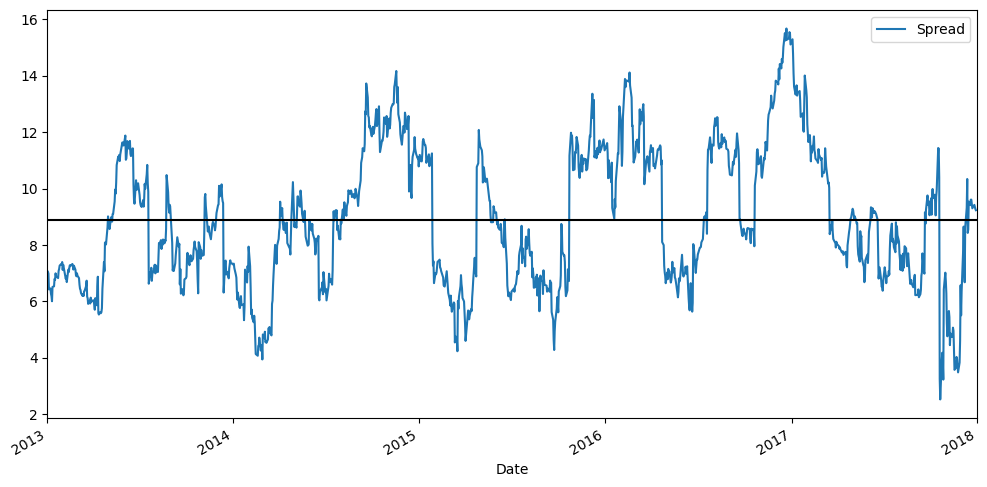

In [41]:
S1 = sm.add_constant(S1)
results = sm.OLS(S2, S1).fit()
S1 = S1['ADBE']
b = results.params['ADBE']

spread = S2 - b * S1
spread.plot(figsize=(12,6))
plt.axhline(spread.mean(), color='black')
plt.xlim('2013-01-01', '2018-01-01')
plt.legend(['Spread']);

### Explanation of the meaning of "trading the spread":

In a cointegrated pair trading strategy, 'trading the spread' refers to exploiting the long-term, statistically stable relationship between the prices of two cointegrated assets. Here's a breakdown:

**Cointegrated Pair**: When two (or more) non-stationary time series are cointegrated, it means they move together in the long run, and a linear combination of them is stationary. This stationary linear combination is often referred to as the 'spread' or 'error correction term'. Even though individual asset prices might wander, their relationship tends to revert to a mean.

**The Spread**: The 'spread' is typically defined as the difference between the price of one asset and a scaled price of the other asset (e.g., Spread = Price_Y - beta * Price_X, where beta is the hedge ratio obtained from a regression, as we saw with b for ADBE and MSFT). Because the assets are cointegrated, this spread is expected to be stationary, meaning it will fluctuate around a constant mean.

**Trading the Spread Strategy (Mean Reversion):**

Execution:

When the spread deviates significantly above its historical mean (meaning one asset is relatively overvalued compared to the other), you would sell the overvalued asset and buy the undervalued asset. For example, if Price_Y - beta * Price_X is high, you'd sell Y and buy X.

**Closing Position**: The goal is to profit when the spread reverts to its mean. Once the spread returns to its average, you would close both positions, realizing a profit.
